# Poem Sentiment Classification with Transformers


## Goal

We want to classify poems into sentiment categories.

1. **classical baseline**: TF-IDF + Logistic Regression;
2. **standard Transformer model**: DistilBERT fine-tuned with the default cross-entropy loss;
3. **weighted-loss Transformer model**: DistilBERT fine-tuned with class-weighted cross-entropy to better handle class imbalance;
4. proper train / validation / test splits;
5. evaluation with Accuracy, Macro-F1, Precision, Recall and confusion matrices;
6. direct comparison between the baseline, the standard Transformer and the weighted-loss Transformer;
7. error analysis and inference examples.


## 1. Setup

This notebook is designed to run locally or on Google Colab.

Recommended environment:

```bash
pip install -r requirements.txt
```

If you use Colab, run the next cell once.


In [ ]:
!pip install -q datasets transformers evaluate accelerate scikit-learn matplotlib seaborn pandas torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.3 MB/s eta 0:00:00


In [4]:

import os
import random
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset, Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

sns.set_theme(style="whitegrid")


## 2. Configuration

We define all important choices in one place:
- seed;
- dataset name;
- model name;
- maximum sequence length;
- training hyperparameters;
- separate output folders for the standard and weighted-loss Transformer runs.

Keeping this explicit makes the project easier to reproduce.


In [5]:

SEED = 42
DATASET_NAME = "poem_sentiment"
MODEL_NAME = "distilbert-base-uncased"

MAX_LENGTH = 128
TEST_SIZE = 0.20
VAL_SIZE = 0.20

BATCH_SIZE = 16
NUM_EPOCHS = 5
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

STANDARD_OUTPUT_DIR = "../models/distilbert-poem-sentiment-standard"
WEIGHTED_OUTPUT_DIR = "../models/distilbert-poem-sentiment-weighted-loss"

FINAL_STANDARD_SAVE_DIR = "../models/final-distilbert-poem-sentiment-standard"
FINAL_WEIGHTED_SAVE_DIR = "../models/final-distilbert-poem-sentiment-weighted-loss"
FINAL_BEST_SAVE_DIR = "../models/final-distilbert-poem-sentiment-best"


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cuda'

## 3. Load Dataset

We load the `poem_sentiment` dataset from Hugging Face.

Instead of relying blindly on predefined splits, we build our own fixed stratified split.  
This avoids leakage and makes the comparison between baseline and Transformer fair.


In [6]:

raw = load_dataset(DATASET_NAME)
raw


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/35.6k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/6.34k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/6.16k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/892 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/105 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/104 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'verse_text', 'label'],
        num_rows: 892
    })
    validation: Dataset({
        features: ['id', 'verse_text', 'label'],
        num_rows: 105
    })
    test: Dataset({
        features: ['id', 'verse_text', 'label'],
        num_rows: 104
    })
})

In [7]:

# Convert all available splits into a single DataFrame.
frames = []
for split_name, ds in raw.items():
    tmp = ds.to_pandas()
    tmp["original_split"] = split_name
    frames.append(tmp)

df = pd.concat(frames, ignore_index=True)

# Identify text column robustly.
candidate_text_columns = ["verse_text", "text", "poem", "sentence"]
text_col = next((c for c in candidate_text_columns if c in df.columns), None)

if text_col is None:
    raise ValueError(f"Could not find a text column. Available columns: {df.columns.tolist()}")

df = df.rename(columns={text_col: "text"})
df = df[["text", "label", "original_split"]].copy()
df["text"] = df["text"].astype(str)

df.head()


,text,label,original_split
0,with pale blue berries. in these peaceful shad...,1,train
1,"it flows so long as falls the rain,",2,train
2,"and that is why, the lonesome day,",0,train
3,"when i peruse the conquered fame of heroes, an...",3,train
4,of inward strife for truth and liberty.,3,train


In [8]:

# Recover label names if the dataset defines a ClassLabel feature.
first_split = list(raw.keys())[0]
label_feature = raw[first_split].features["label"]

if hasattr(label_feature, "names") and label_feature.names is not None:
    label_names = list(label_feature.names)
else:
    label_names = [str(i) for i in sorted(df["label"].unique())]

id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in id2label.items()}

df["label_name"] = df["label"].map(id2label)

print("Number of samples:", len(df))
print("Labels:", id2label)
df.head()


Number of samples: 1101
Labels: {0: 'negative', 1: 'positive', 2: 'no_impact', 3: 'mixed'}


,text,label,original_split,label_name
0,with pale blue berries. in these peaceful shad...,1,train,positive
1,"it flows so long as falls the rain,",2,train,no_impact
2,"and that is why, the lonesome day,",0,train,negative
3,"when i peruse the conquered fame of heroes, an...",3,train,mixed
4,of inward strife for truth and liberty.,3,train,mixed


## 4. Exploratory Data Analysis

Before training, we inspect:
- class distribution;
- text length distribution;
- length by class.

This is important because small or imbalanced datasets can make Transformer fine-tuning unstable.


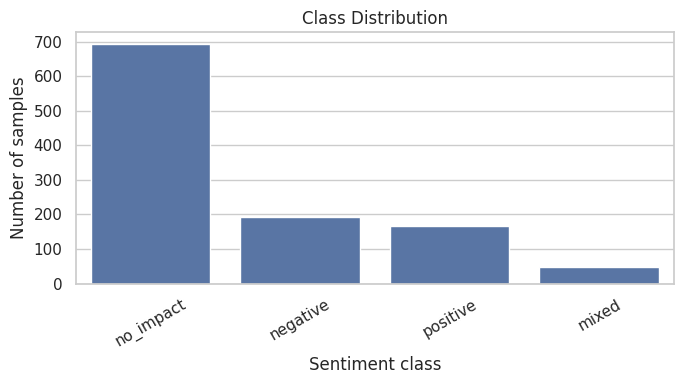

In [9]:

plt.figure(figsize=(7, 4))
order = df["label_name"].value_counts().index
sns.countplot(data=df, x="label_name", order=order)
plt.title("Class Distribution")
plt.xlabel("Sentiment class")
plt.ylabel("Number of samples")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


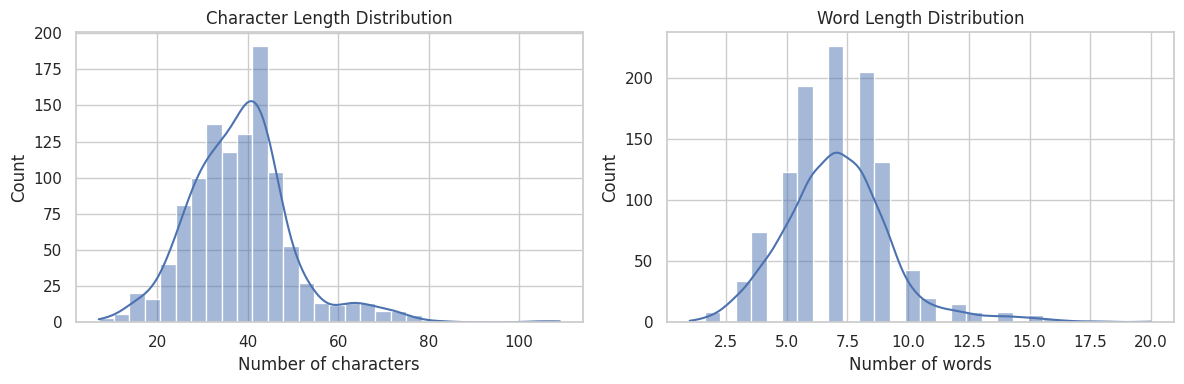

In [10]:

df["char_length"] = df["text"].str.len()
df["word_length"] = df["text"].str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["char_length"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Character Length Distribution")
axes[0].set_xlabel("Number of characters")

sns.histplot(df["word_length"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Word Length Distribution")
axes[1].set_xlabel("Number of words")

plt.tight_layout()
plt.show()


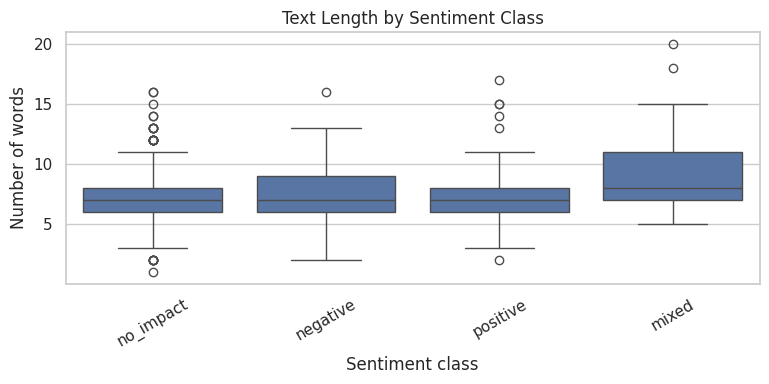

In [11]:

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="label_name", y="word_length", order=order)
plt.title("Text Length by Sentiment Class")
plt.xlabel("Sentiment class")
plt.ylabel("Number of words")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [12]:

# Show a few examples per class.
for label_name in label_names:
    print("\n" + "=" * 80)
    print(label_name.upper())
    print("=" * 80)
    examples = df[df["label_name"] == label_name]["text"].sample(
        min(3, len(df[df["label_name"] == label_name])),
        random_state=SEED
    ).tolist()
    for i, example in enumerate(examples, 1):
        print(f"{i}. {example}")



NEGATIVE
1. but homesick tears would fill the eyes
2. and make the liveliest monkey melancholy.
3. daily struggling, though unloved and lonely,

POSITIVE
1. and virtue's bright image, enstamped on the mind,
2. alas! their right to joy is plain.
3. seed-field of simpler manners, braver truth,

NO_IMPACT
1. and willing grow old
2. o graves of men who lived and died
3. came sages urging on his foamy steed:

MIXED
1. the quavering thunder thereupon had ceas'd,
2. does beauty slight you from her gay abodes?
3. and _channing_, with his bland, superior look,


## 5. Clean Train / Validation / Test Split

A key improvement over a quick notebook is to split the raw examples **before tokenization and training**.

We use a stratified split to preserve class proportions.


In [13]:

train_val_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=df["label"],
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=train_val_df["label"],
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

split_summary = pd.DataFrame({
    "train": train_df["label_name"].value_counts(normalize=True),
    "val": val_df["label_name"].value_counts(normalize=True),
    "test": test_df["label_name"].value_counts(normalize=True),
}).fillna(0)

split_summary


Train: (704, 6)
Validation: (176, 6)
Test: (221, 6)


,train,val,test
label_name,,,
no_impact,0.629261,0.630682,0.628959
negative,0.174716,0.176136,0.176471
positive,0.151989,0.147727,0.149321
mixed,0.044034,0.045455,0.045249


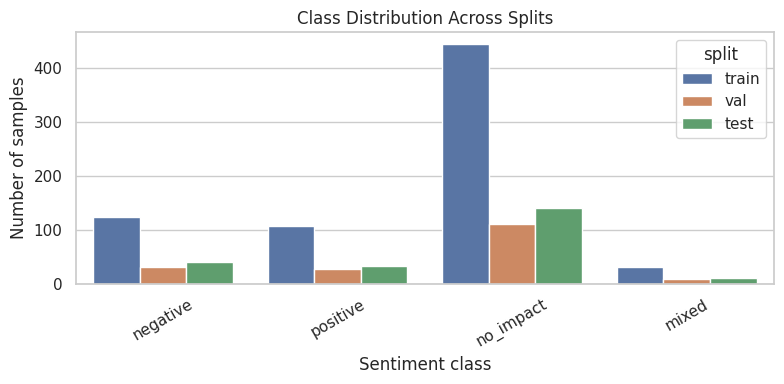

In [14]:

split_counts = pd.concat([
    train_df.assign(split="train"),
    val_df.assign(split="val"),
    test_df.assign(split="test"),
])

plt.figure(figsize=(8, 4))
sns.countplot(data=split_counts, x="label_name", hue="split", order=label_names)
plt.title("Class Distribution Across Splits")
plt.xlabel("Sentiment class")
plt.ylabel("Number of samples")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 6. Baseline: TF-IDF + Logistic Regression

Before using a Transformer, we train a simple baseline.

The baseline already uses `class_weight="balanced"`, which makes it a useful classical comparison point against the weighted-loss Transformer.


In [15]:

baseline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=1,
        max_features=5000,
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=SEED,
    )),
])

baseline.fit(train_df["text"], train_df["label"])
baseline_preds = baseline.predict(test_df["text"])

baseline_metrics = {
    "accuracy": accuracy_score(test_df["label"], baseline_preds),
    "macro_f1": f1_score(test_df["label"], baseline_preds, average="macro"),
    "weighted_f1": f1_score(test_df["label"], baseline_preds, average="weighted"),
    "macro_precision": precision_score(test_df["label"], baseline_preds, average="macro", zero_division=0),
    "macro_recall": recall_score(test_df["label"], baseline_preds, average="macro", zero_division=0),
}

baseline_metrics


{'accuracy': 0.5927601809954751,
 'macro_f1': 0.33651120038668475,
 'weighted_f1': 0.5714883185162389,
 'macro_precision': 0.34098143236074274,
 'macro_recall': 0.3360542335362479}

In [16]:

print(classification_report(
    test_df["label"],
    baseline_preds,
    target_names=label_names,
    zero_division=0,
))


              precision    recall  f1-score   support

    negative       0.27      0.21      0.23        39
    positive       0.38      0.33      0.35        33
   no_impact       0.72      0.81      0.76       139
       mixed       0.00      0.00      0.00        10

    accuracy                           0.59       221
   macro avg       0.34      0.34      0.34       221
weighted avg       0.56      0.59      0.57       221



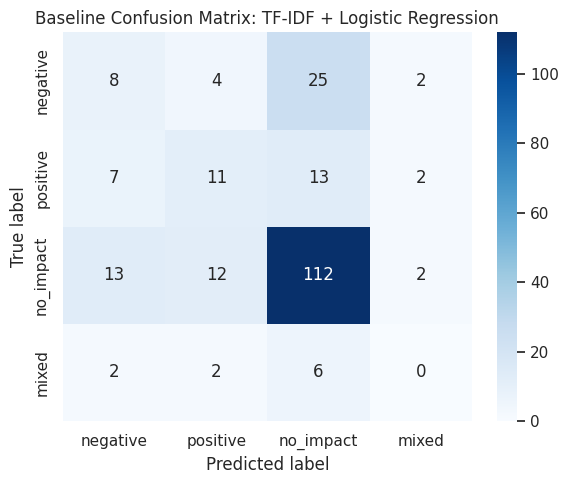

In [17]:

def plot_confusion_matrix(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(labels))))
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
    )
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(
    test_df["label"],
    baseline_preds,
    label_names,
    "Baseline Confusion Matrix: TF-IDF + Logistic Regression",
)


## 7. Transformer Dataset Preparation

We now prepare the dataset for DistilBERT.

The tokenizer converts each poem into token IDs and attention masks.


In [18]:

train_dataset = Dataset.from_pandas(train_df[["text", "label"]].reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df[["text", "label"]].reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df[["text", "label"]].reset_index(drop=True))

dataset = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset,
    "test": test_dataset,
})

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
    )


tokenized_dataset = dataset.map(tokenize_batch, batched=True)
tokenized_dataset = tokenized_dataset.remove_columns(["text"])
tokenized_dataset.set_format("torch")

tokenized_dataset


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/704 [00:00<?, ? examples/s]

Map:   0%|          | 0/176 [00:00<?, ? examples/s]

Map:   0%|          | 0/221 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 704
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 176
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 221
    })
})

## 8. Shared Transformer Utilities

The two Transformer experiments must be identical except for the loss function.

We define helper functions to:
- build a fresh DistilBERT model for each run;
- compute the same metrics for both runs;
- create `TrainingArguments` in a way that works with both recent and older versions of `transformers`;
- create a `Trainer` while handling the `processing_class` / `tokenizer` API difference across versions.


In [19]:

num_labels = len(label_names)


def build_model():
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
    )
    return model.to(device)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
        "macro_precision": precision_score(labels, preds, average="macro", zero_division=0),
        "macro_recall": recall_score(labels, preds, average="macro", zero_division=0),
    }


def evaluate_predictions(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }


def create_training_args(output_dir, run_name):
    # Create TrainingArguments with compatibility for old/new transformers versions.
    args = {
        "output_dir": output_dir,
        "save_strategy": "epoch",
        "logging_strategy": "epoch",
        "learning_rate": LEARNING_RATE,
        "per_device_train_batch_size": BATCH_SIZE,
        "per_device_eval_batch_size": BATCH_SIZE,
        "num_train_epochs": NUM_EPOCHS,
        "weight_decay": WEIGHT_DECAY,
        "load_best_model_at_end": True,
        "metric_for_best_model": "macro_f1",
        "greater_is_better": True,
        "seed": SEED,
        "report_to": "none",
        "run_name": run_name,
    }

    # `eval_strategy` is used by newer transformers versions.
    # Older versions used `evaluation_strategy`.
    training_args_params = inspect.signature(TrainingArguments.__init__).parameters
    if "eval_strategy" in training_args_params:
        args["eval_strategy"] = "epoch"
    else:
        args["evaluation_strategy"] = "epoch"

    return TrainingArguments(**args)


def create_trainer(trainer_cls, model, training_args, train_dataset, eval_dataset, **extra_kwargs):
    # Create a Trainer with compatibility for tokenizer/processing_class changes.
    trainer_kwargs = {
        "model": model,
        "args": training_args,
        "train_dataset": train_dataset,
        "eval_dataset": eval_dataset,
        "compute_metrics": compute_metrics,
        "callbacks": [EarlyStoppingCallback(early_stopping_patience=2)],
    }

    trainer_params = inspect.signature(Trainer.__init__).parameters
    if "processing_class" in trainer_params:
        trainer_kwargs["processing_class"] = tokenizer
    else:
        trainer_kwargs["tokenizer"] = tokenizer

    trainer_kwargs.update(extra_kwargs)
    return trainer_cls(**trainer_kwargs)


## 9. Fine-tune DistilBERT: Standard Loss

This is the original Transformer pipeline: DistilBERT fine-tuned with the default cross-entropy loss.

We keep this run unchanged so that we can compare it fairly with the weighted-loss version.


In [20]:

set_seed(SEED)

model_standard = build_model()
training_args_standard = create_training_args(
    output_dir=STANDARD_OUTPUT_DIR,
    run_name="distilbert-standard-loss",
)

trainer_standard = create_trainer(
    trainer_cls=Trainer,
    model=model_standard,
    training_args=training_args_standard,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
)

trainer_standard


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [21]:

standard_train_result = trainer_standard.train()
standard_train_result


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
1,1.078917,0.955505,0.630682,0.193380,0.487844,0.157670,0.250000
2,0.837586,0.833345,0.630682,0.193380,0.487844,0.157670,0.250000
3,0.683778,0.794678,0.710227,0.366238,0.645136,0.553151,0.383442
4,0.582749,0.776939,0.710227,0.388391,0.661701,0.553823,0.408242
5,0.530069,0.776275,0.727273,0.481798,0.710586,0.514805,0.485528


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=220, training_loss=0.7426196098327636, metrics={'train_runtime': 76.0724, 'train_samples_per_second': 46.272, 'train_steps_per_second': 2.892, 'total_flos': 116575468584960.0, 'train_loss': 0.7426196098327636, 'epoch': 5.0})

## 10. Fine-tune DistilBERT: Weighted Loss

The dataset is imbalanced: the majority class is much more frequent than the minority classes.

To test whether class imbalance hurts the Transformer, we add a second DistilBERT run with a **class-weighted cross-entropy loss**.

The weight for each class is computed only on the training split, then injected into a custom `Trainer`.


In [22]:

train_labels = train_df["label"].to_numpy()
classes = np.arange(num_labels)

class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_labels,
)

class_weights = torch.tensor(class_weights_np, dtype=torch.float)

class_counts = train_df["label"].value_counts().reindex(classes, fill_value=0).sort_index()
class_weight_df = pd.DataFrame({
    "label_id": classes,
    "label_name": [id2label[i] for i in classes],
    "train_count": class_counts.values,
    "class_weight": class_weights_np,
})

class_weight_df


,label_id,label_name,train_count,class_weight
0,0,negative,123,1.430894
1,1,positive,107,1.644860
2,2,no_impact,443,0.397291
3,3,mixed,31,5.677419


In [23]:

class WeightedLossTrainer(Trainer):
    # Trainer using class-weighted cross-entropy for imbalanced classification.

    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        if class_weights is None:
            raise ValueError("class_weights must be provided for WeightedLossTrainer.")
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # The default data collator usually converts `label` to `labels`.
        labels = inputs.pop("labels", None)
        if labels is None:
            labels = inputs.pop("label", None)
        if labels is None:
            raise ValueError("No labels found in the input batch.")

        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = torch.nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device)
        )
        loss = loss_fct(
            logits.view(-1, model.config.num_labels),
            labels.view(-1),
        )

        return (loss, outputs) if return_outputs else loss


In [24]:

set_seed(SEED)

model_weighted = build_model()
training_args_weighted = create_training_args(
    output_dir=WEIGHTED_OUTPUT_DIR,
    run_name="distilbert-weighted-loss",
)

trainer_weighted = create_trainer(
    trainer_cls=WeightedLossTrainer,
    model=model_weighted,
    training_args=training_args_weighted,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    class_weights=class_weights,
)

trainer_weighted


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [25]:

weighted_train_result = trainer_weighted.train()
weighted_train_result


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
1,1.380793,1.353232,0.664773,0.417314,0.640744,0.440083,0.433634
2,1.256227,1.158215,0.750000,0.534934,0.742798,0.509293,0.575140
3,0.921520,0.974948,0.715909,0.522534,0.712875,0.496347,0.586427
4,0.637177,0.880215,0.750000,0.599058,0.749078,0.761783,0.636301
5,0.520194,0.871426,0.750000,0.542353,0.741474,0.510574,0.595679


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=220, training_loss=0.9431822516701438, metrics={'train_runtime': 81.9803, 'train_samples_per_second': 42.937, 'train_steps_per_second': 2.684, 'total_flos': 116575468584960.0, 'train_loss': 0.9431822516701438, 'epoch': 5.0})

## 11. Training Curves

We visualize training and validation curves from both Trainer logs.

The goal is to compare whether the weighted-loss run changes optimization behavior, validation Macro-F1, and validation loss.


In [26]:

logs_standard = pd.DataFrame(trainer_standard.state.log_history)
logs_weighted = pd.DataFrame(trainer_weighted.state.log_history)

print("Standard loss logs:")
display(logs_standard.head())

print("Weighted loss logs:")
display(logs_weighted.head())


Standard loss logs:


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_macro_f1,eval_weighted_f1,eval_macro_precision,eval_macro_recall,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.078917,2.685298,0.000016,1.0,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,44,0.955505,0.630682,0.19338,0.487844,0.15767,0.25,0.6177,284.916,17.807,NaN,NaN,NaN,NaN,NaN
2,0.837586,8.923873,0.000012,2.0,88,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,88,0.833345,0.630682,0.19338,0.487844,0.15767,0.25,0.7027,250.452,15.653,NaN,NaN,NaN,NaN,NaN
4,0.683778,6.735101,0.000008,3.0,132,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Weighted loss logs:


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_macro_f1,eval_weighted_f1,eval_macro_precision,eval_macro_recall,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.380793,2.607943,0.000016,1.0,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,44,1.353232,0.664773,0.417314,0.640744,0.440083,0.433634,0.5968,294.901,18.431,NaN,NaN,NaN,NaN,NaN
2,1.256227,5.521798,0.000012,2.0,88,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,88,1.158215,0.750000,0.534934,0.742798,0.509293,0.575140,0.6003,293.163,18.323,NaN,NaN,NaN,NaN,NaN
4,0.921520,6.560101,0.000008,3.0,132,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


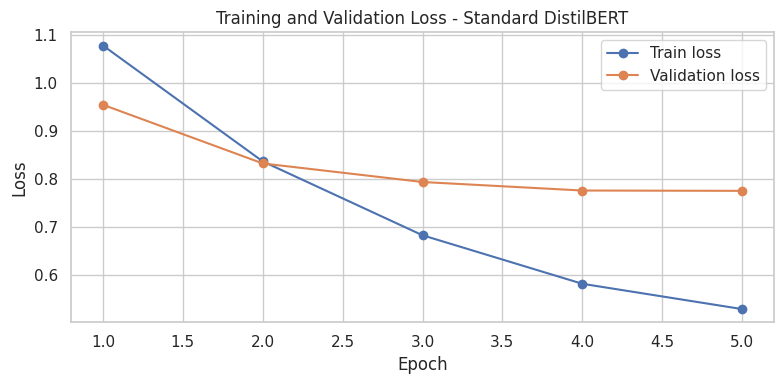

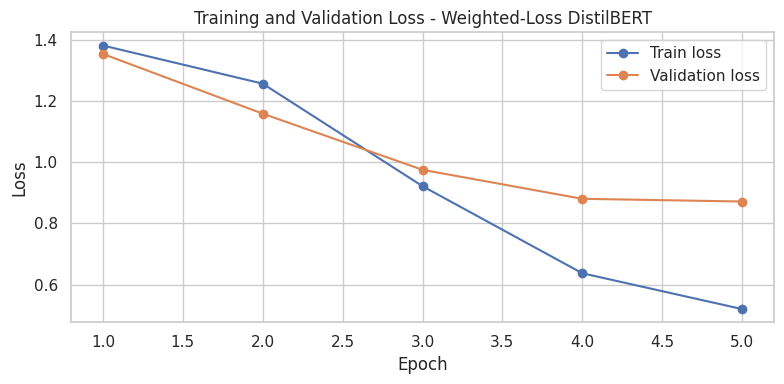

In [27]:

def plot_loss_curves(logs, title):
    plt.figure(figsize=(8, 4))

    if "loss" in logs.columns:
        train_logs = logs.dropna(subset=["loss"])
        plt.plot(train_logs["epoch"], train_logs["loss"], marker="o", label="Train loss")

    if "eval_loss" in logs.columns:
        eval_logs = logs.dropna(subset=["eval_loss"])
        plt.plot(eval_logs["epoch"], eval_logs["eval_loss"], marker="o", label="Validation loss")

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_loss_curves(logs_standard, "Training and Validation Loss - Standard DistilBERT")
plot_loss_curves(logs_weighted, "Training and Validation Loss - Weighted-Loss DistilBERT")


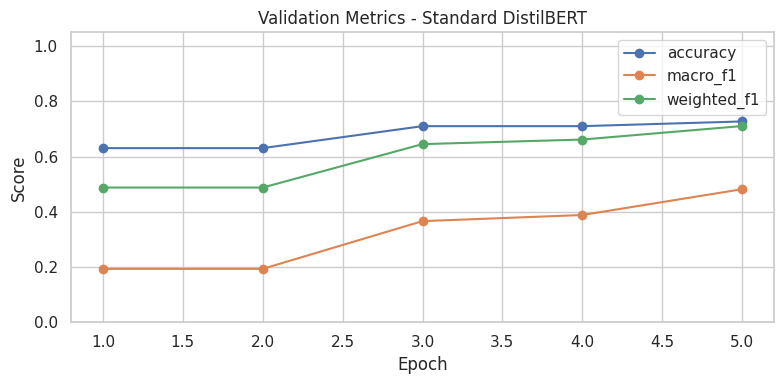

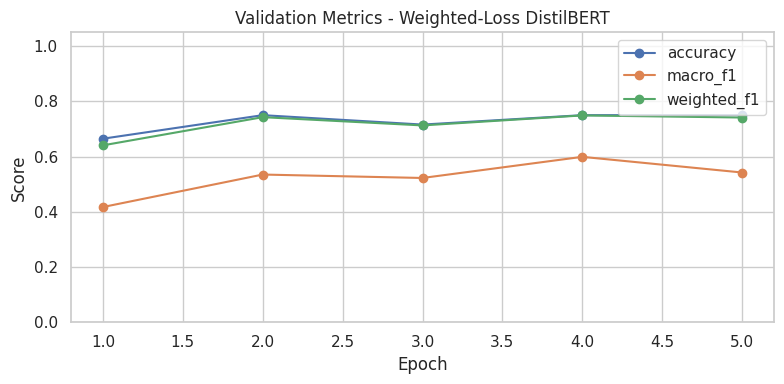

In [28]:

def plot_validation_metrics(logs, title):
    metric_cols = [c for c in ["eval_accuracy", "eval_macro_f1", "eval_weighted_f1"] if c in logs.columns]

    if metric_cols:
        eval_logs = logs.dropna(subset=metric_cols, how="all")
        plt.figure(figsize=(8, 4))
        for col in metric_cols:
            plt.plot(eval_logs["epoch"], eval_logs[col], marker="o", label=col.replace("eval_", ""))
        plt.title(title)
        plt.xlabel("Epoch")
        plt.ylabel("Score")
        plt.ylim(0, 1.05)
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print(f"No validation metric columns found in logs for: {title}")


plot_validation_metrics(logs_standard, "Validation Metrics - Standard DistilBERT")
plot_validation_metrics(logs_weighted, "Validation Metrics - Weighted-Loss DistilBERT")


In [29]:

def extract_best_validation_metrics(logs, model_name):
    eval_logs = logs.dropna(subset=["eval_macro_f1"]).copy()
    if eval_logs.empty:
        return {"model": model_name}

    best_row = eval_logs.sort_values("eval_macro_f1", ascending=False).iloc[0]
    return {
        "model": model_name,
        "best_epoch": best_row.get("epoch", np.nan),
        "best_eval_macro_f1": best_row.get("eval_macro_f1", np.nan),
        "best_eval_accuracy": best_row.get("eval_accuracy", np.nan),
        "best_eval_weighted_f1": best_row.get("eval_weighted_f1", np.nan),
        "best_eval_loss": best_row.get("eval_loss", np.nan),
    }


validation_comparison_df = pd.DataFrame([
    extract_best_validation_metrics(logs_standard, "DistilBERT standard loss"),
    extract_best_validation_metrics(logs_weighted, "DistilBERT weighted loss"),
])

validation_comparison_df


,model,best_epoch,best_eval_macro_f1,best_eval_accuracy,best_eval_weighted_f1,best_eval_loss
0,DistilBERT standard loss,5.0,0.481798,0.727273,0.710586,0.776275
1,DistilBERT weighted loss,4.0,0.599058,0.750000,0.749078,0.880215


## 12. Test Evaluation

We now evaluate both Transformer checkpoints on the same held-out test set.

This section keeps the original test evaluation, but applies it to:
- the standard DistilBERT model;
- the weighted-loss DistilBERT model.


In [30]:

def predict_with_trainer(trainer, split="test"):
    output = trainer.predict(tokenized_dataset[split])
    logits = output.predictions
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    confidence = probs.max(axis=1)

    return {
        "output": output,
        "logits": logits,
        "preds": preds,
        "probs": probs,
        "confidence": confidence,
    }


standard_test = predict_with_trainer(trainer_standard, split="test")
weighted_test = predict_with_trainer(trainer_weighted, split="test")

standard_metrics = evaluate_predictions(test_df["label"], standard_test["preds"])
weighted_metrics = evaluate_predictions(test_df["label"], weighted_test["preds"])

transformer_test_metrics_df = pd.DataFrame([
    {"model": "DistilBERT standard loss", **standard_metrics},
    {"model": "DistilBERT weighted loss", **weighted_metrics},
])

transformer_test_metrics_df


,model,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
0,DistilBERT standard loss,0.778281,0.537536,0.756686,0.551058,0.534412
1,DistilBERT weighted loss,0.778281,0.596332,0.779799,0.605000,0.621112


In [31]:

print("STANDARD DISTILBERT")
print(classification_report(
    test_df["label"],
    standard_test["preds"],
    target_names=label_names,
    zero_division=0,
))

print("\n" + "=" * 80 + "\n")

print("WEIGHTED-LOSS DISTILBERT")
print(classification_report(
    test_df["label"],
    weighted_test["preds"],
    target_names=label_names,
    zero_division=0,
))


STANDARD DISTILBERT
              precision    recall  f1-score   support

    negative       0.58      0.64      0.61        39
    positive       0.79      0.58      0.67        33
   no_impact       0.83      0.92      0.87       139
       mixed       0.00      0.00      0.00        10

    accuracy                           0.78       221
   macro avg       0.55      0.53      0.54       221
weighted avg       0.74      0.78      0.76       221



WEIGHTED-LOSS DISTILBERT
              precision    recall  f1-score   support

    negative       0.75      0.77      0.76        39
    positive       0.50      0.79      0.61        33
   no_impact       0.92      0.83      0.87       139
       mixed       0.25      0.10      0.14        10

    accuracy                           0.78       221
   macro avg       0.60      0.62      0.60       221
weighted avg       0.80      0.78      0.78       221



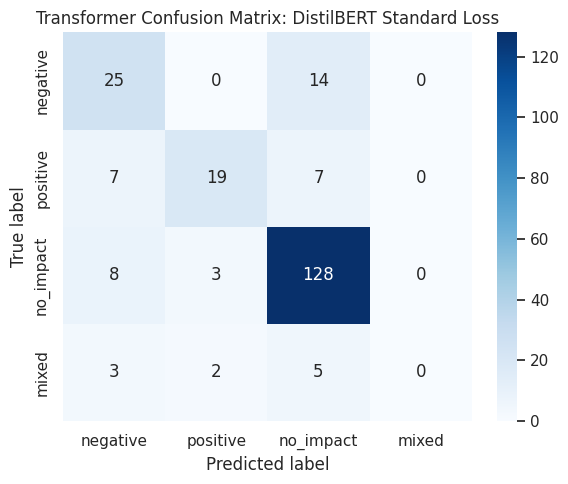

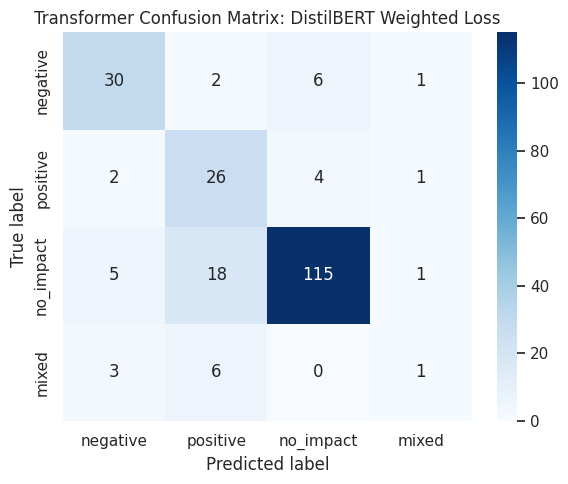

In [32]:

plot_confusion_matrix(
    test_df["label"],
    standard_test["preds"],
    label_names,
    "Transformer Confusion Matrix: DistilBERT Standard Loss",
)

plot_confusion_matrix(
    test_df["label"],
    weighted_test["preds"],
    label_names,
    "Transformer Confusion Matrix: DistilBERT Weighted Loss",
)


## 13. Baseline vs Standard Transformer vs Weighted-Loss Transformer

A real project should compare models directly.

We compare all models using the same test set:
- TF-IDF + Logistic Regression baseline;
- DistilBERT with standard loss;
- DistilBERT with weighted loss.


In [33]:

comparison_df = pd.DataFrame([
    {"model": "TF-IDF + Logistic Regression", **baseline_metrics},
    {"model": "DistilBERT standard loss", **standard_metrics},
    {"model": "DistilBERT weighted loss", **weighted_metrics},
])

comparison_df


,model,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
0,TF-IDF + Logistic Regression,0.592760,0.336511,0.571488,0.340981,0.336054
1,DistilBERT standard loss,0.778281,0.537536,0.756686,0.551058,0.534412
2,DistilBERT weighted loss,0.778281,0.596332,0.779799,0.605000,0.621112


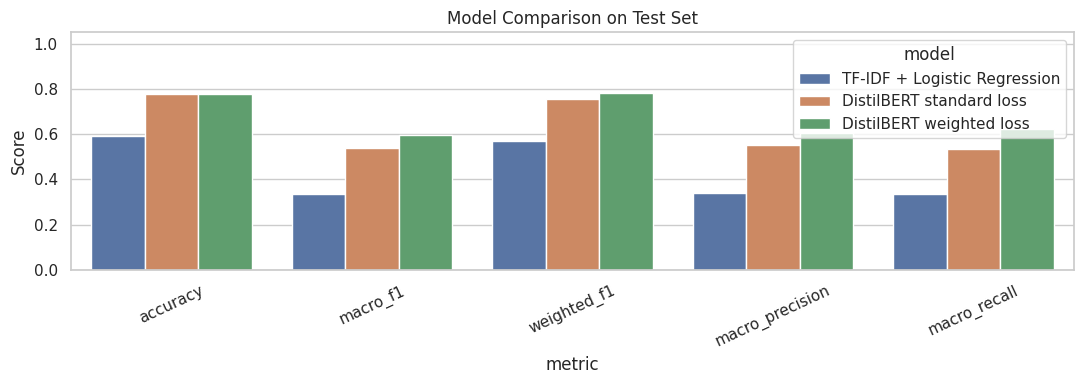

In [34]:

melted = comparison_df.melt(id_vars="model", var_name="metric", value_name="score")

plt.figure(figsize=(11, 4))
sns.barplot(data=melted, x="metric", y="score", hue="model")
plt.title("Model Comparison on Test Set")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


In [35]:

transformer_delta_df = pd.DataFrame({
    "metric": list(standard_metrics.keys()),
    "standard_loss": [standard_metrics[m] for m in standard_metrics.keys()],
    "weighted_loss": [weighted_metrics[m] for m in standard_metrics.keys()],
})
transformer_delta_df["weighted_minus_standard"] = (
    transformer_delta_df["weighted_loss"] - transformer_delta_df["standard_loss"]
)

transformer_delta_df


,metric,standard_loss,weighted_loss,weighted_minus_standard
0,accuracy,0.778281,0.778281,0.000000
1,macro_f1,0.537536,0.596332,0.058796
2,weighted_f1,0.756686,0.779799,0.023113
3,macro_precision,0.551058,0.605000,0.053942
4,macro_recall,0.534412,0.621112,0.086700


## 14. Error Analysis

Instead of only reporting metrics, we inspect wrong predictions.

We first compare the number of test errors made by each Transformer model, then we select the Transformer with the best test Macro-F1 for detailed error analysis.


In [36]:

transformer_results = {
    "standard": {
        "name": "DistilBERT standard loss",
        "trainer": trainer_standard,
        "model": model_standard,
        "preds": standard_test["preds"],
        "probs": standard_test["probs"],
        "confidence": standard_test["confidence"],
        "metrics": standard_metrics,
    },
    "weighted": {
        "name": "DistilBERT weighted loss",
        "trainer": trainer_weighted,
        "model": model_weighted,
        "preds": weighted_test["preds"],
        "probs": weighted_test["probs"],
        "confidence": weighted_test["confidence"],
        "metrics": weighted_metrics,
    },
}

error_summary_df = pd.DataFrame([
    {
        "variant": variant,
        "model": result["name"],
        "num_errors": int(np.sum(test_df["label"].to_numpy() != result["preds"])),
        "error_rate": float(np.mean(test_df["label"].to_numpy() != result["preds"])),
        "test_macro_f1": result["metrics"]["macro_f1"],
    }
    for variant, result in transformer_results.items()
])

error_summary_df


,variant,model,num_errors,error_rate,test_macro_f1
0,standard,DistilBERT standard loss,49,0.221719,0.537536
1,weighted,DistilBERT weighted loss,49,0.221719,0.596332


In [48]:

best_variant = max(
    transformer_results,
    key=lambda variant: transformer_results[variant]["metrics"]["macro_f1"],
)
best_result = transformer_results[best_variant]

print(f"Best Transformer for detailed error analysis: {best_result['name']} ({best_variant})")
print(f"Test Macro-F1: {best_result['metrics']['macro_f1']:.4f}")


Best Transformer for detailed error analysis: DistilBERT weighted loss (weighted)
Test Macro-F1: 0.5963


,model_variant,model_name,num_errors,total_examples,error_rate,macro_f1
0,standard,DistilBERT standard loss,49,221,0.221719,0.537536
1,weighted,DistilBERT weighted loss,49,221,0.221719,0.596332


text,true_name,pred_name,confidence
"""i rather should have hewn your limbs away,",negative,no_impact,0.957635
"and, between the river flowing and the fair green trees a-growing,",positive,no_impact,0.954045
"false-faces hung on strings,",negative,no_impact,0.953909
when the glance hast lost its beam;,negative,no_impact,0.941698
if men are always at a loss,negative,no_impact,0.941629
"dark with more clouds than tempests are,",negative,no_impact,0.934635
"good ringers, pull your best,"" quoth he.",positive,no_impact,0.931747
"dauntless he rose, and to the fight return’d;",positive,no_impact,0.898855
"with the earls of the goths about her: so queenly did she seem,",positive,no_impact,0.867289
obliterate the etchings,negative,no_impact,0.861352


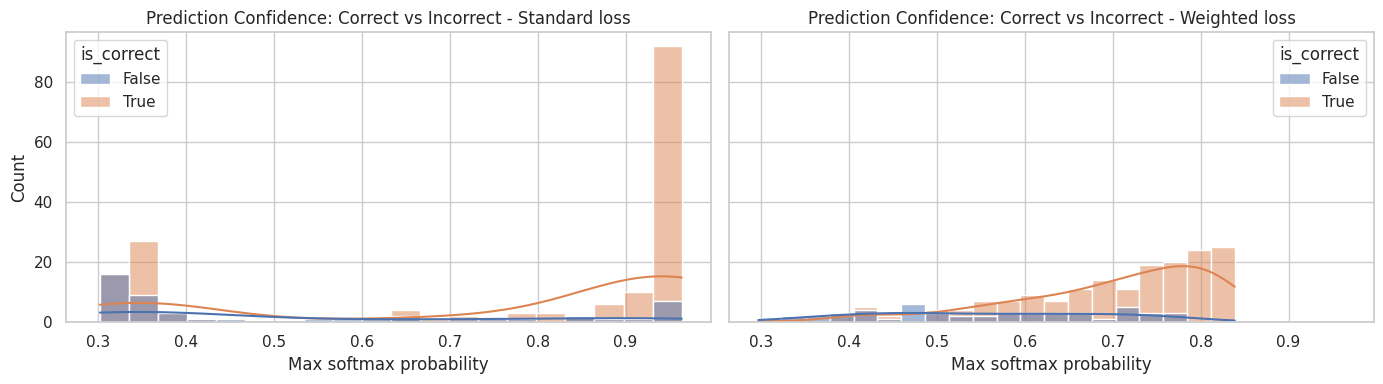

In [51]:
from IPython.display import display, HTML

def build_error_df(result, variant):
    df = test_df.copy().reset_index(drop=True)
    df["pred_label"] = result["preds"]
    df["pred_name"] = df["pred_label"].map(id2label)
    df["true_name"] = df["label"].map(id2label)
    df["confidence"] = result["confidence"]
    df["is_correct"] = df["label"] == df["pred_label"]
    df["model_variant"] = variant
    return df


standard_error_df = build_error_df(transformer_results["standard"], "standard")
weighted_error_df = build_error_df(transformer_results["weighted"], "weighted")

standard_errors = (
    standard_error_df[~standard_error_df["is_correct"]]
    .sort_values("confidence", ascending=False)
)

weighted_errors = (
    weighted_error_df[~weighted_error_df["is_correct"]]
    .sort_values("confidence", ascending=False)
)

error_summary_side_by_side = pd.DataFrame([
    {
        "model_variant": "standard",
        "model_name": transformer_results["standard"]["name"],
        "num_errors": len(standard_errors),
        "total_examples": len(standard_error_df),
        "error_rate": len(standard_errors) / len(standard_error_df),
        "macro_f1": transformer_results["standard"]["metrics"]["macro_f1"],
    },
    {
        "model_variant": "weighted",
        "model_name": transformer_results["weighted"]["name"],
        "num_errors": len(weighted_errors),
        "total_examples": len(weighted_error_df),
        "error_rate": len(weighted_errors) / len(weighted_error_df),
        "macro_f1": transformer_results["weighted"]["metrics"]["macro_f1"],
    },
])

display(error_summary_side_by_side)


standard_top_errors = standard_errors[
    ["text", "true_name", "pred_name", "confidence"]
].head(10)

weighted_top_errors = weighted_errors[
    ["text", "true_name", "pred_name", "confidence"]
].head(10)

display(HTML(f"""
<div style="display: flex; gap: 24px; align-items: flex-start;">
    <div style="width: 50%;">
        <h3>Standard loss - Top 10 high-confidence errors</h3>
        {standard_top_errors.to_html(index=False, escape=True)}
    </div>
    <div style="width: 50%;">
        <h3>Weighted loss - Top 10 high-confidence errors</h3>
        {weighted_top_errors.to_html(index=False, escape=True)}
    </div>
</div>
"""))


fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True)

sns.histplot(
    data=standard_error_df,
    x="confidence",
    hue="is_correct",
    bins=20,
    kde=True,
    ax=axes[0],
)

axes[0].set_title("Prediction Confidence: Correct vs Incorrect - Standard loss")
axes[0].set_xlabel("Max softmax probability")

sns.histplot(
    data=weighted_error_df,
    x="confidence",
    hue="is_correct",
    bins=20,
    kde=True,
    ax=axes[1],
)

axes[1].set_title("Prediction Confidence: Correct vs Incorrect - Weighted loss")
axes[1].set_xlabel("Max softmax probability")

plt.tight_layout()
plt.show()

In [ ]:

error_df = test_df.copy().reset_index(drop=True)
error_df["pred_label"] = best_result["preds"]
error_df["pred_name"] = error_df["pred_label"].map(id2label)
error_df["true_name"] = error_df["label"].map(id2label)
error_df["confidence"] = best_result["confidence"]
error_df["is_correct"] = error_df["label"] == error_df["pred_label"]
error_df["model_variant"] = "standard"

errors = error_df[~error_df["is_correct"]].sort_values("confidence", ascending=False)


In [40]:

if len(errors) > 0:
    for i, row in errors.head(5).iterrows():
        print("=" * 100)
        print("TEXT:", row["text"])
        print("TRUE:", row["true_name"])
        print("PRED:", row["pred_name"])
        print("CONFIDENCE:", round(row["confidence"], 3))
else:
    print("No errors found on this test split.")


TEXT: "i rather should have hewn your limbs away,
TRUE: negative
PRED: no_impact
CONFIDENCE: 0.778
TEXT: false-faces hung on strings,
TRUE: negative
PRED: no_impact
CONFIDENCE: 0.778
TEXT: but the great spirit plants it in our hearts,
TRUE: no_impact
PRED: positive
CONFIDENCE: 0.766
TEXT: while with thy childlike faith we lean
TRUE: no_impact
PRED: positive
CONFIDENCE: 0.749
TEXT: of peace? it is thy father's name. thy life
TRUE: no_impact
PRED: positive
CONFIDENCE: 0.739


## 15. Inference Function

We define a small function to predict the sentiment of new poem lines.

By default, the function uses the Transformer variant with the best test Macro-F1 in this notebook run.  
You can also force a variant with `variant="standard"` or `variant="weighted"`.


In [41]:

def predict_sentiment(texts, variant=None):
    if isinstance(texts, str):
        texts = [texts]

    if variant is None:
        variant = best_variant

    if variant not in transformer_results:
        raise ValueError(f"Unknown variant: {variant}. Choose one of {list(transformer_results.keys())}.")

    selected_model = transformer_results[variant]["model"]
    selected_model.eval()

    inputs = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    ).to(device)

    with torch.no_grad():
        logits = selected_model(**inputs).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()

    preds = probs.argmax(axis=1)

    results = []
    for text, pred, prob in zip(texts, preds, probs):
        results.append({
            "model_variant": variant,
            "text": text,
            "predicted_label": id2label[int(pred)],
            "confidence": float(prob[pred]),
            "probabilities": {id2label[i]: float(p) for i, p in enumerate(prob)},
        })

    return pd.DataFrame(results)


predict_sentiment([
    "The night is cold but hope is still burning.",
    "My heart breaks under the silent rain.",
    "The river moves without sadness or joy.",
])


,model_variant,text,predicted_label,confidence,probabilities
0,weighted,The night is cold but hope is still burning.,negative,0.462322,"{'negative': 0.46232184767723083, 'positive': ..."
1,weighted,My heart breaks under the silent rain.,negative,0.426770,"{'negative': 0.4267696440219879, 'positive': 0..."
2,weighted,The river moves without sadness or joy.,positive,0.483012,"{'negative': 0.13770732283592224, 'positive': ..."


In [42]:

# Optional: compare both Transformer variants on the same custom examples.
example_texts = [
    "The night is cold but hope is still burning.",
    "My heart breaks under the silent rain.",
    "The river moves without sadness or joy.",
]

pd.concat([
    predict_sentiment(example_texts, variant="standard"),
    predict_sentiment(example_texts, variant="weighted"),
], ignore_index=True)


,model_variant,text,predicted_label,confidence,probabilities
0,standard,The night is cold but hope is still burning.,negative,0.333667,"{'negative': 0.3336673974990845, 'positive': 0..."
1,standard,My heart breaks under the silent rain.,negative,0.322048,"{'negative': 0.3220476508140564, 'positive': 0..."
2,standard,The river moves without sadness or joy.,negative,0.321021,"{'negative': 0.3210214078426361, 'positive': 0..."
3,weighted,The night is cold but hope is still burning.,negative,0.462322,"{'negative': 0.46232184767723083, 'positive': ..."
4,weighted,My heart breaks under the silent rain.,negative,0.426770,"{'negative': 0.4267696440219879, 'positive': 0..."
5,weighted,The river moves without sadness or joy.,positive,0.483012,"{'negative': 0.13770732283592224, 'positive': ..."


## 16. Save Models and Tokenizer

This makes the project reusable outside the notebook.

We save:
- the standard-loss DistilBERT model;
- the weighted-loss DistilBERT model;
- the best Transformer variant according to test Macro-F1.


In [43]:

trainer_standard.save_model(FINAL_STANDARD_SAVE_DIR)
tokenizer.save_pretrained(FINAL_STANDARD_SAVE_DIR)

trainer_weighted.save_model(FINAL_WEIGHTED_SAVE_DIR)
tokenizer.save_pretrained(FINAL_WEIGHTED_SAVE_DIR)

best_result["trainer"].save_model(FINAL_BEST_SAVE_DIR)
tokenizer.save_pretrained(FINAL_BEST_SAVE_DIR)

print(f"Standard-loss model and tokenizer saved to: {FINAL_STANDARD_SAVE_DIR}")
print(f"Weighted-loss model and tokenizer saved to: {FINAL_WEIGHTED_SAVE_DIR}")
print(f"Best model and tokenizer saved to: {FINAL_BEST_SAVE_DIR}")
print(f"Best variant: {best_result['name']} ({best_variant})")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Standard-loss model and tokenizer saved to: ../models/final-distilbert-poem-sentiment-standard
Weighted-loss model and tokenizer saved to: ../models/final-distilbert-poem-sentiment-weighted-loss
Best model and tokenizer saved to: ../models/final-distilbert-poem-sentiment-best
Best variant: DistilBERT weighted loss (weighted)
